![TU Delft logo](https://raw.githubusercontent.com/robot144/wi4475_2026/main/images/tu_logo.png)
# Homework series 1 for Data Assimilation course (WI4475 2026)

This is the first homework series for the data assimilation course (WI4475 2026). There are 2 questions with 5 subquestions each. For each of these 10 subquestions you can earn one point, which directly sums to the grade for this homework series. The code in this documents works with Jupyter with a Julia kernel. With that set-up you can just add the answers after each question and generate a pdf from the notebook when you are done.

Please submit your completed homework series as a single pdf file via Brightspace before de deadline given there.

The files for this homework series are all available [here](https://github.com/robot144/wi4475_2026). 

Good luck and feel free to reach out if you have any questions!

Martin

---
## Julia and Jupyter

This homework was created using Jupyter with a Julia kernel. Jupyter is a notebook system where one can combine text and code into one document that contains a list of cells. Each cell can contain code or text. Unlike the commonly used  Python language, Julia is a language that was designed from the start to be fast. It can be used for numerical computing in a way that is very similar to python in the computation cells, once the Julia kernel is installed. 
Intallation instructions for Julia with Jupyter can be found [in the README.md](https://github.com/robot144/wi4475_2026)


    
---


In [1]:
# Install some packages if you don't have them yet
# This will take a while the first time you run it (especially 
# the DifferentialEquations package).

using Pkg
packages=["Plots", "LaTeXStrings", "DifferentialEquations"]
Pkg.add(packages)
for p in packages
    #Pkg.add(p)
    println("using $p")
    @eval using $(Symbol(p))
end


    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


using Plots
using LaTeXStrings
using DifferentialEquations


---
## Question 1: Stability of a groundwater flow model

In the first question we will analyze the stability of a simple groundwater flow model with storage. The model descibes the flow of groundwater in a 1D aquifer with storage.
At first the hydraulic head is zero everywhere and the flow is zero. At the left boundary, the hydraulic head increases gradually from 0 to 1, while at the right boundary the hydraulic head is kept at zero. This causes groundwater to flow from the left to the right boundary. The hydralic head conceptually represents the pressure of the groundwater.

The governing equations for the groundwater flow with storage are given by:

$$q=-K \frac{\partial h}{\partial x}$$
$$S \frac{\partial h}{\partial t}=-\frac{\partial q}{\partial x}$$
Where $h$ is the hydraulic head, $q$ is the specific discharge, $K$ is the hydraulic conductivity and $S$ is the storage coefficient. We use domain $x \in [0,L]$, with:
$$h(t=0)==0$$
$$h(x=0,t)=1-e^{-t/T}$$
$$h(x=L,t)=0$$

We choose:

- $S = 10^{-4} [1/m]$
- $K = 5+5*\frac{4}{L^2}*x*(L-x) [m/day]$
- $L = 10^4 [m]$
- $T = 10 [day]$

---
### 1a: 

Compute the stationary solution for $t \to \infty$. First write down the equation for $\frac{\partial h}{\partial t}=0$ and then solve it analytically.

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### Spatial discretization

To solve this numerically, we semi-discretize the spatial domain for $h$ into $N$ grid points with spacing $\Delta x=L/(N-1)$. We denote the discrete hydraulic head at grid point $i$ and time $t$ as $h_i(t)$. The spatial derivative can be approximated using central differences on a staggered grid. The discrete equations for the interior grid points are then given by:

- $q_{i+1/2}=-K_{i+1/2} \frac{h_{i+1}-h_i}{\Delta x}$ for $i=1,2,...,N-1$
- $\frac{d h_i}{d t}=\frac{-1}{S} \frac{q_{i+1/2} - q_{i-1/2}}{\Delta x}$ for $i=2,3,...,N-1$
with boundary conditions:
- $h_1(t)=1-e^{-t/T}$
- $h_N(t)=0$

In [18]:
# The following code solves the groundwater flow model with 
# storage to give some intuition of the system's behavior. 
# The code is based on the equations and parameters 
# given in the question.

# Define the model
function profile(dh_dt, h, p, t)
    S,K,L,T=p #unpack parameters
    n=length(h)
    Δx=L/(n-1)
    h[1]=h_left(t,T) # left boundary condition
    h[end]=0.0       # right boundary condition
    q=zeros(eltype(h),n-1) #flow profile
    for k in 1:length(q) 
        q[k]=-K[k]*(h[k+1]-h[k])/Δx
    end
    # compute dh_dt
    dh_dt[1]=h_left_deriv(t,T) # derivative of left boundary condition
    dh_dt[end]=0.0              # derivative of right boundary condition
    for k in 2:n-1
        dh_dt[k]=-(q[k]-q[k-1])/(S*Δx)
    end
    # nothing to return, dh_dt is modified in place
end
    
function h_left(t,T) # left boundary condition h(0,t)
    return 1.0- exp(-t/T)
end
function h_left_deriv(t,T) # derivative of left boundary condition
    return (1.0/T)*exp(-t/T)
end

h_left_deriv (generic function with 1 method)

In [27]:
# Now run and plot the results

#plotting a single time profile of h
function plot_profile(h, t, p)
    S,K,L,T=p
    n=length(h)
    Δx=L/(n-1)
    x=collect(0:Δx:L) # x values for h
    plot(x/1000, h, title="t=$(t)",label=false, ylims=(0,1),xlims=(0,L/1000))
    xlabel!("x [km]")
    ylabel!("h [m]")
end

function animate_profile(sol, p, timestep=2.0, fps=10)
    # create an animation
    times = sol.t[1]:timestep:sol.t[end] # times at which to plot the solution
    nt = length(times)
    anim = @animate for i in 1:nt
            u=sol(times[i])
            plot_profile(u,times[i],p)
    end
    return gif(anim, fps = fps)
end



animate_profile (generic function with 3 methods)

  0.007615 seconds (66.63 k allocations: 26.925 MiB)
  3.075266 seconds (682.81 k allocations: 41.057 MiB, 0.34% gc time, 1.26% compilation time)


Plots.AnimatedGif("/tmp/jl_DCtAza94da.gif")
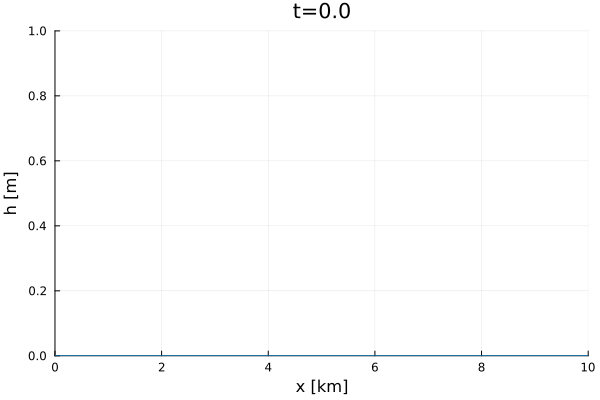

┌ Info: Saved animation to /tmp/jl_DCtAza94da.gif
└ @ Plots /home/verlaan/.julia/packages/Plots/zgMHY/src/animation.jl:156


In [28]:
S=0.0001  # storage coefficient [1/m]
L=10000.0 # length of the aquifer [m]
T=10.0 # time scale for left boundary condition [days]
n=100     # number of discrete points in x direction for h
x_h=collect(0.0:L/(n-1):L) # x values for h
Δx=L/(n-1) # grid spacing
x_q=x_h[1:end-1].+Δx/2 # x values for q (midpoints of the cells)
K=5.0 .+ 5.0 .* (4.0 ./ L^2) .* x_q .* (L .- x_q) # hydraulic conductivity
p = (S,K,L,T) # parameters tuple
h_0 = zeros(n)

tspan=(0.0,200.0) # time span for the simulation [days]

prob=ODEProblem(profile,h_0,tspan,p)
@time sol=solve(prob, alg_hints=[:stiff])
@time gif_animation=animate_profile(sol,p)

#plot(sol(15.0),z)
#plot_profile(sol(150.0),150.0,p)

# you can save the animation using
# cp(gif_animation.filename, "groundwater.gif"; force=true)
display(gif_animation)

---
### 1b:

Write the semi-discretized equations in standard system notation:
$$\frac{d \mathbf{x}}{d t}=\mathbf{A}\mathbf{x}+\mathbf{B}\mathbf{u}$$
where $\mathbf{x}$ is the state vector (containing the discrete hydraulic head values $h_i$), $\mathbf{u}$ is the input vector, and $\mathbf{A}$ and $\mathbf{B}$ are matrices that you need to define. And what is input function $\mathbf{u}(t)$?

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 1c: 

Next, we'll analyze the stability of the semi-discretized system, using the matrix $\mathbf{A}$ from 1b. The eigenvalues of $\mathbf{A}$ determine the stability of the system.

First show that $\mathbf{A}$ is symmetric and that a symmetric matrix has only real eigenvalues.


__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 1d:

Continuing from 1c, please compute the eigenvalues of $\mathbf{A}$ numerically and determine whether the semidiscretized system is stable or not.

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 1e:

Discretize the system $\frac{d \mathbf{x}}{d t}=\mathbf{A}\mathbf{x}+\mathbf{B}\mathbf{u}$ in time using the forward Euler method. Write down the update equation for $\mathbf{x}$ at time step $n+1$ in terms of $\mathbf{x}$ at time step $n$, in the standard form:
$$\mathbf{x}^{n+1} = \tilde{\mathbf{A}} \mathbf{x}_n + \tilde{\mathbf{B}} \mathbf{u}_n$$

How does the stability of the system depend on the eigenvalues of $\mathbf{A}$ and the time step $\Delta t$ used in the forward Euler method?

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
## Exercise 2: probability and statistics

In this question, we will work with Gaussian random variables and vectors, and consider different propoeries of these. And we will also look at possible transformations of Gaussian random variables and vectors.

To get started, consider a Gaussian random vector $\mathbf{X}$ with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{C}$, denoted as $\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu},\boldsymbol{C})$.


---
## 2a

We will often use the fact that a linear transformation of a Gaussian random vector is also Gaussian. In this exercise you will show this for a simple linear transformation.

Let $\mathbf{w}$ be a random vector  of length $n$ with independent Gaussian elements $w_i  \sim \mathcal{N}(0,1)$
and let $\mathbf{x}=\mathbf{L}\mathbf{w}+\mathbf{b}$ where $\mathbf{L} \in \Re^{n,n}$ and $b \in \Re^n$.

First, show that $\mathbf{x}$ has a Gaussian distribution function, using the distribution functions for $w_i$. Next, if we're given the mean $\mathbf{\mu}$ and covariance matrix $\mathbf{C}$, how do we find a vector $\mathbf{b}$ and matrix $\mathbf{L}$ such that we can generate a random vector $\mathbf{x}$ with this mean and covariance from a vector $\mathbf{w}$ of independent standard Gaussians?

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 2b

Use the answer of 2a to generate a sample of size $N=100$ with mean $\mu=[1, 1]'$ and covariance  $\mathbf{C}=\begin{pmatrix} 1 & \rho \\\rho & 1\end{pmatrix}$  use eg `w=randn(2,N)`. Create a scatterplot `scatter(x,y)`. Use $\rho=0.9$ for the samples and plot.
Now compute the eigenvalues and eigenvectors for $\mathbf{C}$ and scale them with $\sqrt{\lambda_i}$. Add these vectors to the plot. Let the vectors start at $\mu$. What do you observe?

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### Auto-covariances

Consider the following Matérn auto-covariance functions $c_0((h)$ and $c_1(h)$:
$$c_0(h)=\sigma^2 e^{-h/d}$$
$$c_1(h)=\sigma^2 (1+ \frac{\sqrt{3}h}{d}) e^{-\sqrt{3}h/d}$$
where $h$ is the distance between two points, $\sigma^2$ is the variance and $d$ is the length scale. 

These auto-covariance functions are special cases of the Matern auto-covariance [Matern covariance function](https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function) for $p=0 \to \nu=1/2$ and $p=1 \to\nu=3/2$.

The code below plots these auto-covariance functions. You can change the parameters $\sigma^2$ and $d$ to see how they affect the shape of the auto-covariance functions.

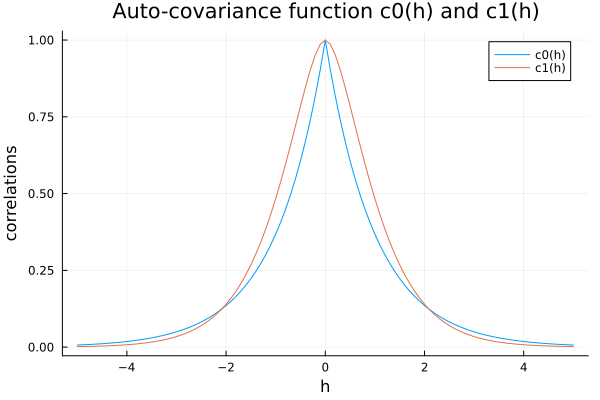

In [4]:
# Plotting the auto-covariance functions c_0 and c_1
Δ=0.1
L=5.0
x=-L:Δ:L
function c0(h,σ=1.0,d=1.0)
    return σ^2 * exp(-h/d)
end
# $$c_1(h)=\sigma^2 (1+ \frac{\sqrt{3}h}{d}) e^{-\sqrt{3}h/d}$$
function c1(h,σ=1.0,d=1.0)
    return σ^2 * (1.0 + sqrt(3)*h/d) * exp(-sqrt(3)*h/d)
end
xj=0.0 # 
c0_x=[c0(abs(xi - xj)) for xi in x]
c1_x=[c1(abs(xi - xj)) for xi in x]
plot(x, c0_x, xlabel="h", ylabel="correlations", title="Auto-covariance function c0(h) and c1(h)", label="c0(h)")
plot!(x, c1_x, label="c1(h)")

---
### 2c

There exist relationships between the shape of the auto-covariance functions and for example the continuity of the random functions that have these auto-covariances. 

First, let us consider the continuity of the random function with auto-covariance $c_0(h)$. As a first step, show that $lim_{\Delta x \downarrow 0}E[|y(x+\Delta x)-y(x)|^2]$ for random functions with mean zero and auto-covariance $c_0(x)$. What property of the auto-covariance function $c_0$ is important for this? Can you use this to link the shape of the auto-covariance function to the continuity of the random function?

Finally, plot some generated samples to illustrate this. Use a 1D grid $x=0:\Delta x:L$ to generate several approximate samples on this grid (using 1a) for the auto-covariance function $c_0$. 

*If you're worried that we silently moved between random vectors and random functions, you're right! There are fundamental differences, but without going into detail, there shouldn't be any difficulties with this particular exercise. Here the random vectors are just restrictions of the random functions to a grid. The exercise is meant to illustrate the concepts rather than mathematical rigor.*

__Answer__

Your answer goes $h\epsilon r \epsilon$

In [6]:
# code for 2c
myvar=randn(4,3)

4×3 Matrix{Float64}:
  0.482148   1.17585   0.0601575
  0.368525  -1.00356   1.36357
  0.919807  -1.13334  -0.068278
 -0.715853  -1.39756  -2.20195

---
### 2d

In the previous question we studies the continuity of the random function $c_0$. Now also generate some samples for $c_1$ and verify experimentally that samples with both auto-covariances are continuous, but only samples from $c_1$ are differentiable. Any ideas, what property of the auto-covariance function $c_1$ is important for this?

__Answer__

Your answer goes $h\epsilon r \epsilon$

---
### 2e

The last exercise ifs a demonstration of the impact of the auto-covariance function choice on the Kalman measurement update. For this, we will use the Kalman measurement update formulas to show how the choice of auto-covariance function affects the update around the measurement location.

Start with the given initial estimate of a variable $y$ as a function of one spatial coordinate $x$.  The mean $E y_b(x):=0$ on the discrete grid. We can denote these values as a vector $\mathbf{y}_b=0$. The uncertainty of this estimate is described by the auto-covariance functions $c_0$ and $c_1$ that we have been working with in the previous exercises. We can denote these restricted to the grid as covariance matrices $\mathbf{P}_0$ and $\mathbf{P}_1$ for the two auto-covariance functions, respectively.

Next, use the Kalman measurement update formulas to study the impact of a single measurement at a location $x_m$ on the updated estimate of $y$ across the grid. The Kalman measurement update formulas are given by:
$$\mathbf{y}_a=\mathbf{y}_b+\mathbf{K}(\mathbf{z}-\mathbf{H}\mathbf{y}_b)$$
and $$\mathbf{K}=\mathbf{P}\mathbf{H}'(\mathbf{H}\mathbf{P}\mathbf{H}'+\mathbf{R})^{-1}$$

Use these to compute the resulting measurment updates $\mathbf{y}_a$ for the both auto-covariances and for measured value $\mathbf{z}=1$ at $x=x_m$ and $\mathbf{R}=[0.0]$. What do you observe for the continuity and differentiability of the update at the measurement location for both auto-covariance functions. 

__Answer__

Your answer goes $h\epsilon r \epsilon$

In [ ]:
# Code
Δ=0.1
L=5.0
x=-L:Δ:L
x_m=L/2 # measurement location in the middle of the grid
y_b=zeros(length(x)) # background state
z=1.0 # measurement